In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
lap_model = joblib.load("../models/lap_time_model.pkl")
overtake_model = joblib.load("../models/overtake_model.pkl")
pit_model = joblib.load("../models/pit_stop_model.pkl")

print("Models loaded successfully")

Models loaded successfully


In [3]:
df = pd.read_csv("../data/feature_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (145913, 29)


,Driver,DriverEncoded,TeamEncoded,TrackEncoded,Season,RegulationEra,LapNumber,lap_progress,Position,CompoundEncoded,...,WindSpeed,race_time,gap_ahead,gap_behind,traffic_pressure,drs_available,driver_pace_baseline,track_pace_baseline,pace_relative,LapTimeSeconds
0,BOT,6,9,0,2019,0,4.0,0.072727,1.0,1.0,...,2.553435,403.528,NaN,-1.595,NaN,0,100.640170,102.618405,0.148830,100.789
1,VER,36,13,0,2019,0,4.0,0.072727,2.0,1.0,...,2.553435,405.123,1.595,-1.638,3.233,0,100.696642,102.618405,0.314358,101.011
2,HAM,15,9,0,2019,0,4.0,0.072727,3.0,1.0,...,2.553435,406.761,1.638,-3.923,5.561,0,100.665093,102.618405,0.565907,101.231
3,LEC,21,5,0,2019,0,4.0,0.072727,4.0,1.0,...,2.553435,410.684,3.923,-3.779,7.702,0,101.548231,102.618405,-0.044231,101.504
4,NOR,25,8,0,2019,0,4.0,0.072727,5.0,0.0,...,2.553435,414.463,3.779,-0.871,4.650,0,102.327385,102.618405,-0.016385,102.311


In [4]:
race_df = df[df["Season"] == 2024]

race_df = race_df.sort_values(
    ["TrackEncoded","DriverEncoded","LapNumber"]
)

In [5]:
TOTAL_LAPS = int(race_df["LapNumber"].max())

PIT_TIME_LOSS = 20
DRS_THRESHOLD = 1.0
FUEL_BURN_PER_LAP = 1.7

N_SIMULATIONS = 300

In [6]:
def tire_penalty(age):
    return 0.04 * age + 0.002 * age**2

In [7]:
strategies = {

    "soft_medium": {
        "pit_laps": [18],
        "compounds": [0,1]
    },

    "medium_hard": {
        "pit_laps": [25],
        "compounds": [1,2]
    },

    "soft_hard": {
        "pit_laps": [20],
        "compounds": [0,2]
    }

}

In [8]:
def simulate_race(strategy):

    race_state = (
        race_df
        .groupby("DriverEncoded")
        .first()
        .reset_index()
    )

    race_state = race_state.sort_values("Position").reset_index(drop=True)

    race_state["cumulative_time"] = 0.0
    race_state["gap_ahead"] = 0.0
    race_state["gap_behind"] = 0.0
    race_state["traffic_pressure"] = 0.0
    race_state["drs_available"] = 0

    pit_laps = strategy["pit_laps"]
    compounds = strategy["compounds"]

    race_state["CompoundEncoded"] = compounds[0]

    for lap in range(1, TOTAL_LAPS + 1):

        race_state["LapNumber"] = lap
        race_state["lap_progress"] = lap / TOTAL_LAPS

        race_state["tyre_age"] += 1
        race_state["laps_since_pit"] += 1

        race_state["fuel_load"] -= FUEL_BURN_PER_LAP
        race_state["fuel_load"] = race_state["fuel_load"].clip(lower=0)

        race_state["track_evolution"] = lap / TOTAL_LAPS

        lap_features = race_state[
        [
        'DriverEncoded','TeamEncoded','TrackEncoded','Season','RegulationEra',
        'LapNumber','lap_progress','Position','CompoundEncoded','tyre_age',
        'stint_number','pace_trend','laps_since_pit','fuel_load','track_evolution',
        'AirTemp','TrackTemp','Humidity','WindSpeed','gap_ahead','gap_behind',
        'traffic_pressure','drs_available','driver_pace_baseline',
        'track_pace_baseline','pace_relative'
        ]
        ].fillna(0)

        race_state["lap_time"] = lap_model.predict(lap_features)

        race_state["lap_time"] += race_state["tyre_age"].apply(tire_penalty)

        race_state["lap_time"] += race_state["fuel_load"] * 0.025

        driver_error = np.random.normal(0,0.3,len(race_state))
        race_state["lap_time"] += driver_error

        if lap in pit_laps:

            race_state["lap_time"] += PIT_TIME_LOSS

            race_state["tyre_age"] = 0
            race_state["laps_since_pit"] = 0
            race_state["stint_number"] += 1

            stint_index = pit_laps.index(lap) + 1
            race_state["CompoundEncoded"] = compounds[stint_index]

        race_state["cumulative_time"] += race_state["lap_time"]

        race_state = race_state.sort_values("cumulative_time").reset_index(drop=True)

        race_state["Position"] = np.arange(1,len(race_state)+1)

        race_state["gap_ahead"] = (
            race_state["cumulative_time"] -
            race_state["cumulative_time"].shift(1)
        ).fillna(0)

        race_state["gap_behind"] = (
            race_state["cumulative_time"].shift(-1) -
            race_state["cumulative_time"]
        ).fillna(0)

        race_state["gap_ahead"] = race_state["gap_ahead"].clip(0,10)
        race_state["gap_behind"] = race_state["gap_behind"].clip(0,10)

        race_state["traffic_pressure"] = race_state["gap_ahead"] - race_state["gap_behind"]

        race_state["drs_available"] = (
            race_state["gap_ahead"] < DRS_THRESHOLD
        ).astype(int)

        race_state["pace_diff"] = race_state["pace_trend"].diff().fillna(0)

        race_state["tyre_advantage"] = race_state["tyre_age"].diff().fillna(0)

        race_state["close_battle"] = (
            race_state["gap_ahead"] < 1.2
        ).astype(int)

        race_state["closing_speed"] = (
            race_state["gap_ahead"].shift(1) -
            race_state["gap_ahead"]
        ).fillna(0)

        race_state["drs_pressure"] = (
            race_state["drs_available"] *
            np.maximum(0,1-race_state["gap_ahead"])
        )

        race_state["track_overtake_rate"] = 0.15

        overtake_features = race_state[
        [
        "DriverEncoded","TrackEncoded","Season","Position",
        "CompoundEncoded","tyre_age","pace_trend",
        "gap_ahead","gap_behind","traffic_pressure",
        "laps_since_pit","drs_available",
        "pace_diff","tyre_advantage","close_battle",
        "closing_speed","drs_pressure","track_overtake_rate"
        ]
        ].fillna(0)

        overtake_prob = overtake_model.predict_proba(overtake_features)[:,1]

        race_state["overtake"] = np.random.rand(len(race_state)) < overtake_prob

        for i in range(1,len(race_state)):

            if race_state.loc[i,"overtake"] and race_state.loc[i,"gap_ahead"] < 1.2:

                race_state.iloc[[i-1,i]] = race_state.iloc[[i,i-1]].values

    return race_state[["DriverEncoded","Position","cumulative_time"]]

In [10]:
strategy_results = []

for strategy_name, strategy in strategies.items():

    for sim in range(N_SIMULATIONS):

        result = simulate_race(strategy)

        result["strategy"] = strategy_name
        result["simulation"] = sim

        strategy_results.append(result)

    print("Finished:", strategy_name)

Finished: soft_medium
Finished: medium_hard
Finished: soft_hard


In [11]:
results_df = pd.concat(strategy_results)

In [12]:
wins = results_df[results_df["Position"] == 1]

win_prob = wins.groupby("strategy")["DriverEncoded"].count() / N_SIMULATIONS

podiums = results_df[results_df["Position"] <= 3]

podium_prob = podiums.groupby("strategy")["DriverEncoded"].count() / N_SIMULATIONS

avg_position = results_df.groupby("strategy")["Position"].mean()

avg_race_time = results_df.groupby("strategy")["cumulative_time"].mean()

In [14]:
summary = pd.DataFrame({
    "win_probability": win_prob,
    "podium_probability": podium_prob,
    "avg_position": avg_position,
    "avg_race_time": avg_race_time
})

summary.sort_values("avg_position")

,win_probability,podium_probability,avg_position,avg_race_time
strategy,,,,
medium_hard,1.0,3.0,12.5,335.634216
soft_hard,1.0,3.0,12.5,364.864679
soft_medium,1.0,3.0,12.5,380.281042


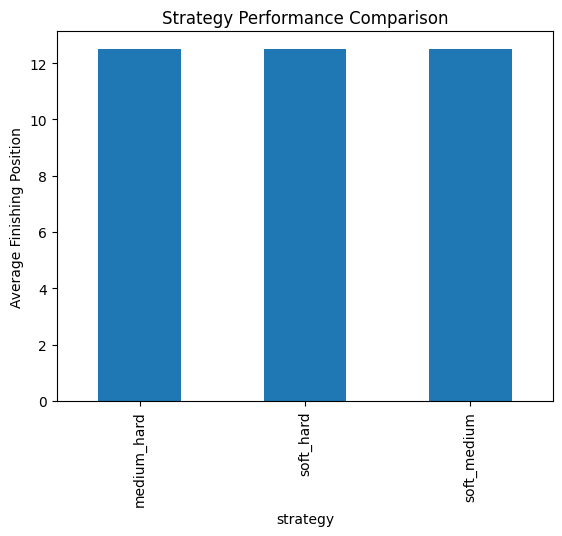

In [15]:
summary["avg_position"].sort_values().plot(kind="bar")

plt.ylabel("Average Finishing Position")
plt.title("Strategy Performance Comparison")

plt.show()

In [16]:
results_df.to_csv("../data/strategy_results.csv", index=False)

print("Strategy simulation results saved")

Strategy simulation results saved


## when notebook closed run this . 

In [ ]:
import pandas as pd

results_df = pd.read_csv("../data/strategy_results.csv")

results_df.head()

## computation metrics

In [ ]:
N_SIMULATIONS = results_df["simulation"].nunique()

wins = results_df[results_df["Position"] == 1]
win_prob = wins.groupby("strategy")["DriverEncoded"].count() / N_SIMULATIONS

podiums = results_df[results_df["Position"] <= 3]
podium_prob = podiums.groupby("strategy")["DriverEncoded"].count() / N_SIMULATIONS

avg_position = results_df.groupby("strategy")["Position"].mean()

avg_race_time = results_df.groupby("strategy")["cumulative_time"].mean()

## Strategy leaderboard

In [ ]:
summary = pd.DataFrame({
    "win_probability": win_prob,
    "podium_probability": podium_prob,
    "avg_position": avg_position,
    "avg_race_time": avg_race_time
})

summary.sort_values("avg_position")

## for steps like Step 7 Monte Carlo
Step 8 Strategy engine
Step 9 RL training
always
Run once
Save results
Reload later

In [1]:
import pandas as pd

df = pd.read_csv("../data/strategy_results.csv")

print(df.head())
print(df.columns)
print(len(df))

   DriverEncoded  Position  cumulative_time     strategy  simulation
0             21         1       152.351884  soft_medium           0
1             30         2       167.456747  soft_medium           0
2             36         3       192.279251  soft_medium           0
3              9         4       248.103807  soft_medium           0
4             32         5       266.265090  soft_medium           0
Index(['DriverEncoded', 'Position', 'cumulative_time', 'strategy',
       'simulation'],
      dtype='object')
21600


In [4]:
import pandas as pd
import os

DATA_PATH = "../data"
files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

report = []

for file in files:
    df = pd.read_csv(os.path.join(DATA_PATH, file))
    report.append({
        "dataset": file,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": ", ".join(df.columns)
    })

report_df = pd.DataFrame(report)
report_df.to_csv("dataset_report.csv", index=False)

print(report_df)

                       dataset    rows  columns  \
0  race_simulation_results.csv    1872       44   
1         strategy_results.csv   21600        5   
2      monte_carlo_results.csv   24000        3   
3       simulation_results.csv    1200       18   
4          feature_dataset.csv  145913       29   
5             race_dataset.csv  159009       26   

                                        column_names  
0  DriverEncoded, TeamEncoded, TrackEncoded, Seas...  
1  DriverEncoded, Position, cumulative_time, stra...  
2                DriverEncoded, Position, simulation  
3  Driver, LapNumber, Position, CompoundEncoded, ...  
4  Driver, DriverEncoded, TeamEncoded, TrackEncod...  
5  Driver, Team, LapNumber, LapTime, Compound, Ty...  
